In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [68]:
def quick_plot(f, w0, res, bounds=(-1.2, 1.2), w_star=(0, 0), levels=None):
    if levels is None:
        levels = [0.5, 2, 5, 10, 20, 50, 80, 110]

    xr = np.linspace(bounds[0], bounds[1], 300)
    yr = np.linspace(bounds[0], bounds[1], 300)
    X_grid, Y_grid = np.meshgrid(xr, yr)
    Z_grid = f(X_grid, Y_grid)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ## fig1. contour
    ax = axes[0]
    ax.contour(X_grid, Y_grid, Z_grid, levels=levels, colors='gray', alpha=0.5)
    ax.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap='Blues', alpha=0.3)

    for r in res:
        path = r['path']
        label = r['label']
        color = r.get('color', None)
        fmt = r.get('fmt', '.-')

        ax.plot(path[:,0], path[:,1], fmt, color=color, markersize=4, linewidth=1.5, label=label)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    ## fig2. loss curve
    ax2 = axes[1]
    for r in res:
        loss = r['loss']
        label = r['label']
        color = r.get('color', None)

        ax2.semilogy(loss, color=color, linewidth=2, label=label)

    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


---
## I. THUẬT TOÁN ADAGRAD

**AdaGrad** giải quyết bài toán tốc độ học thích nghi bằng cách tích lũy **tổng bình phương** toàn bộ lịch sử gradient để điều chỉnh riêng cho từng tham số.

**Công thức cập nhật** tại bước $t$:

$$\mathbf{g}_t = \nabla f(\mathbf{w}_{t-1})$$

$$\mathbf{s}_t = \mathbf{s}_{t-1} + \mathbf{g}_t \odot \mathbf{g}_t$$

$$\mathbf{w}_t = \mathbf{w}_{t-1} - \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t$$

Khởi tạo $\mathbf{s}_0 = \mathbf{0}$, $\epsilon \approx 10^{-8}$ để tránh chia 0. Tất cả phép toán $\odot$, chia, căn thực hiện **element-wise**.

**Cơ chế thích nghi:**
- Tham số có gradient lớn liên tục $\Rightarrow$ $s_t$ lớn $\Rightarrow$ $\frac{\eta}{\sqrt{s_t}}$ **nhỏ** (hãm phanh tự động).
- Tham số có gradient thưa thớt $\Rightarrow$ $s_t$ nhỏ $\Rightarrow$ $\frac{\eta}{\sqrt{s_t}}$ **lớn** (học nhanh khi có cơ hội).

**Nhược điểm:** $\mathbf{s}_t$ chỉ tăng, không bao giờ giảm $\Rightarrow$ $\frac{\eta}{\sqrt{\mathbf{s}_t}} \to 0$ — mô hình ngừng học.


In [69]:
def fn(x, y):
    return x**2 + 100*y**2

def grad_fn(w):
    return np.array([2*w[0], 200*w[1]])

def simple_momentum(grad_fn, w0, lr, gamma, steps):
    w = w0.copy().astype(float)
    v = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        g = grad_fn(w)
        v = gamma * v + lr * g
        w -= v
        path.append(w.copy())
    return np.array(path)

In [70]:
def simple_adagrad(grad_fn, w0, lr, steps, eps = 1e-8):
    weights = w0.copy().astype(float)
    st = np.zeros_like(weights)
    path = [weights.copy()]
    for _ in range(steps):
        g = grad_fn(weights)
        st += g**2
        weights -= lr / (np.sqrt(st  + eps)) * g
        path.append(weights.copy())
    return np.array(path)

In [71]:
w0 = np.array([1.0, 1.0])
steps = 200

# moment
path_mom = simple_momentum(grad_fn, w0, lr=0.005, gamma=0.9, steps=steps)
losses_mom = [fn(p[0], p[1]) for p in path_mom]

# ada
path_ada = simple_adagrad(grad_fn, w0, lr=0.5, steps=steps)
losses_ada = [fn(p[0], p[1]) for p in path_ada]

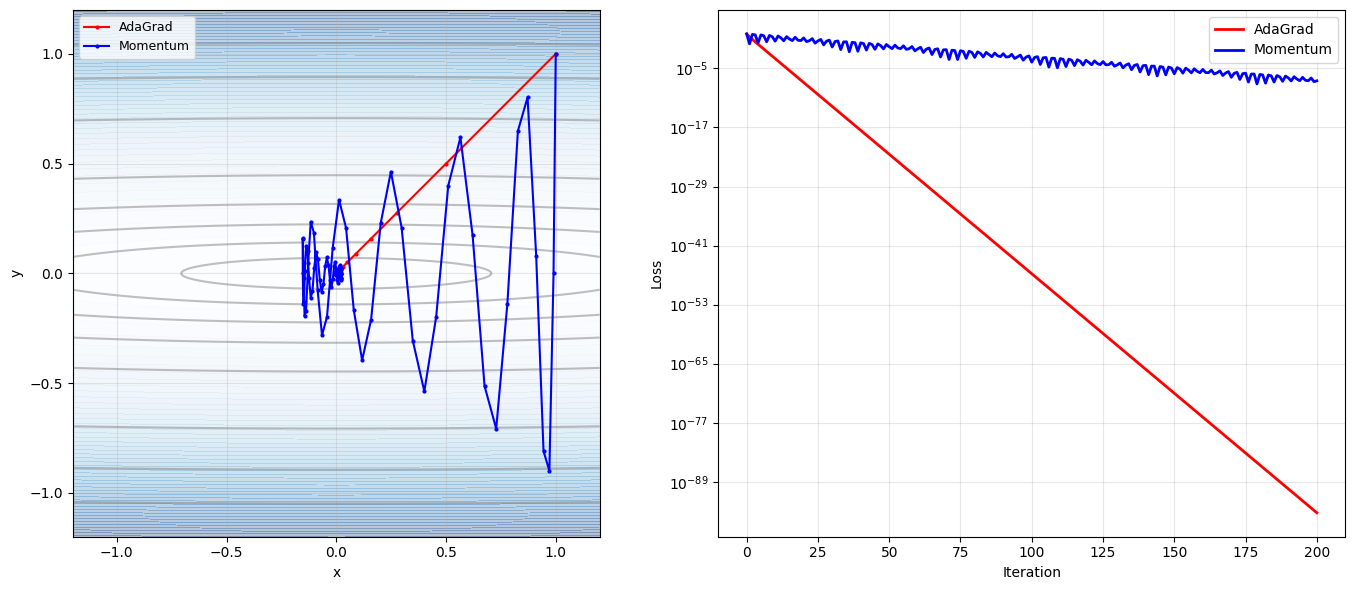

In [72]:
plot_data = [
    {'path': path_ada, 'label': 'AdaGrad', 'color': 'r', 'fmt': '.-', 'loss': losses_ada},
    {'path': path_mom, 'label': 'Momentum', 'color': 'b', 'fmt': '.-', 'loss': losses_mom},
]

quick_plot(fn, w0, plot_data)

---
## II. THUẬT TOÁN RMSPROP

**RMSProp** khắc phục nhược điểm của AdaGrad bằng cách thay tổng tích lũy bằng **Trung bình động lũy thừa (EMA)** — chỉ nhớ gradient **gần đây**, quên dần quá khứ xa.

**Công thức cập nhật** tại bước $t$:

$$\mathbf{g}_t = \nabla f(\mathbf{w}_{t-1})$$

$$\mathbf{s}_t = \beta\, \mathbf{s}_{t-1} + (1-\beta)\, \mathbf{g}_t \odot \mathbf{g}_t$$

$$\mathbf{w}_t = \mathbf{w}_{t-1} - \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t$$

Khởi tạo $\mathbf{s}_0 = \mathbf{0}$, thường chọn $\beta = 0.9$.

**Tại sao RMSProp không bị triệt tiêu?** Nếu $g_t = c$ ổn định, chuỗi $s_t$ hội tụ về:
$$s_\infty = c^2 \quad \Rightarrow \quad \tilde{\eta}_\infty = \frac{\eta}{|c|} > 0$$
Tốc độ học ổn định, không về 0.

**Khoảng thời gian bộ nhớ hiệu quả:** $\approx \dfrac{1}{1-\beta}$

| $\beta$ | Window $\approx$ |
|---------|------------------|
| 0.9     | 10 bước          |
| 0.99    | 100 bước         |
| 0.999   | 1000 bước        |


In [73]:
def simple_rmsp(grad_fn, w0, lr, steps, beta=0.9, eps=1e-8):
    w = w0.copy().astype(float)
    s = np.zeros_like(w)
    path = [w.copy()]
    for _ in range(steps):
        g = grad_fn(w)

        s = beta * s + (1 - beta) * g**2
        w -= lr / (np.sqrt(s + eps)) * g
        path.append(w.copy())
    return np.array(path)

In [74]:
w0 = np.array([-0.8, 1.0])
steps = 160

# ada
path_ada = simple_adagrad(grad_fn, w0, lr=0.3, steps=steps)
losses_ada = [fn(p[0], p[1]) for p in path_ada]

# rms
path_rms = simple_rmsp(grad_fn, w0, lr=0.01, steps=steps, beta=0.9)
losses_rms = [fn(p[0], p[1]) for p in path_rms]

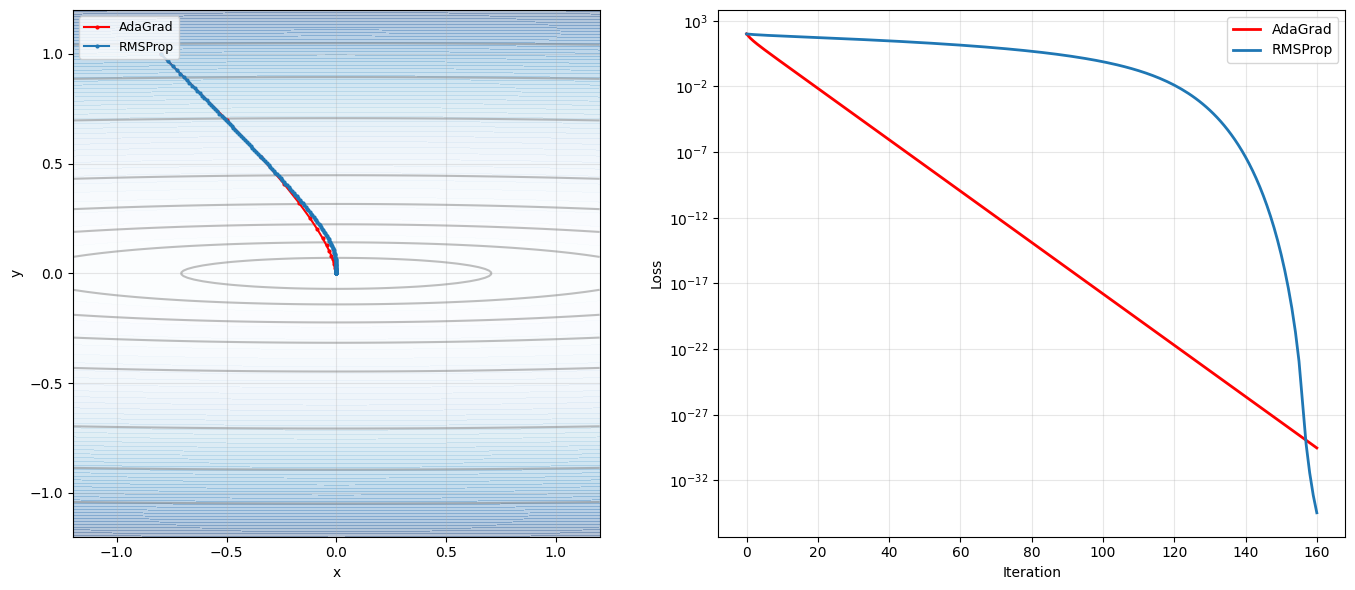

In [75]:
plot_data = [
    {'path': path_ada, 'label': 'AdaGrad', 'color': 'r', 'fmt': '.-', 'loss': losses_ada},
    {'path': path_rms, 'label': 'RMSProp', '  color': 'g', 'fmt': '.-', 'loss': losses_rms},
]

quick_plot(fn, w0, plot_data)

---
## III. THUẬT TOÁN ADAM

**Adam** (Adaptive Moment Estimation, Kingma & Ba 2014) kết hợp **Momentum** (moment bậc 1 — quán tính) và **RMSProp** (moment bậc 2 — giảm chấn).

**Công thức cập nhật** tại bước $t$:

$$\mathbf{g}_t = \nabla f(\mathbf{w}_{t-1})$$

$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1-\beta_1)\mathbf{g}_t \qquad \text{(Moment bậc 1)}$$

$$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1-\beta_2)\mathbf{g}_t \odot \mathbf{g}_t \qquad \text{(Moment bậc 2)}$$

**Hiệu chỉnh chệch** (Bias Correction) — bù cho việc khởi tạo $\mathbf{m}_0 = \mathbf{v}_0 = \mathbf{0}$:

$$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1-\beta_1^t}, \qquad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1-\beta_2^t}$$

**Luật cập nhật:**

$$\mathbf{w}_t = \mathbf{w}_{t-1} - \frac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \odot \hat{\mathbf{m}}_t$$

Mặc định: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$.

**Tính chất — Giới hạn vận tốc:** Khi $t \to \infty$ với $g_t = g$ không đổi:
$$|\Delta w_\infty| = \eta \quad \Rightarrow \quad \text{bước nhảy không bao giờ vượt quá } \eta$$


In [76]:
def simple_adam(grad_fn, w0, lr, steps, beta1=0.9, beta2=0.999, eps=1e-8):
    w = w0.copy().astype(float)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = [w.copy()]

    for step in range(1, steps + 1):
        g = grad_fn(w)

        # Momentum
        m = beta1 * m + (1 - beta1) * g
        # RMSProp
        v = beta2 * v + (1 - beta2) * g**2

        # Bias correction
        m_hat = m / (1 - beta1**step)
        v_hat = v / (1 - beta2**step)

        w -= lr / (np.sqrt(v_hat) + eps) * m_hat
        path.append(w.copy())
    return np.array(path)

In [77]:
path_adam = simple_adam(grad_fn, w0, lr=0.1, steps=steps, beta1 = 0.5)
losses_adam = [fn(p[0], p[1]) for p in path_adam]

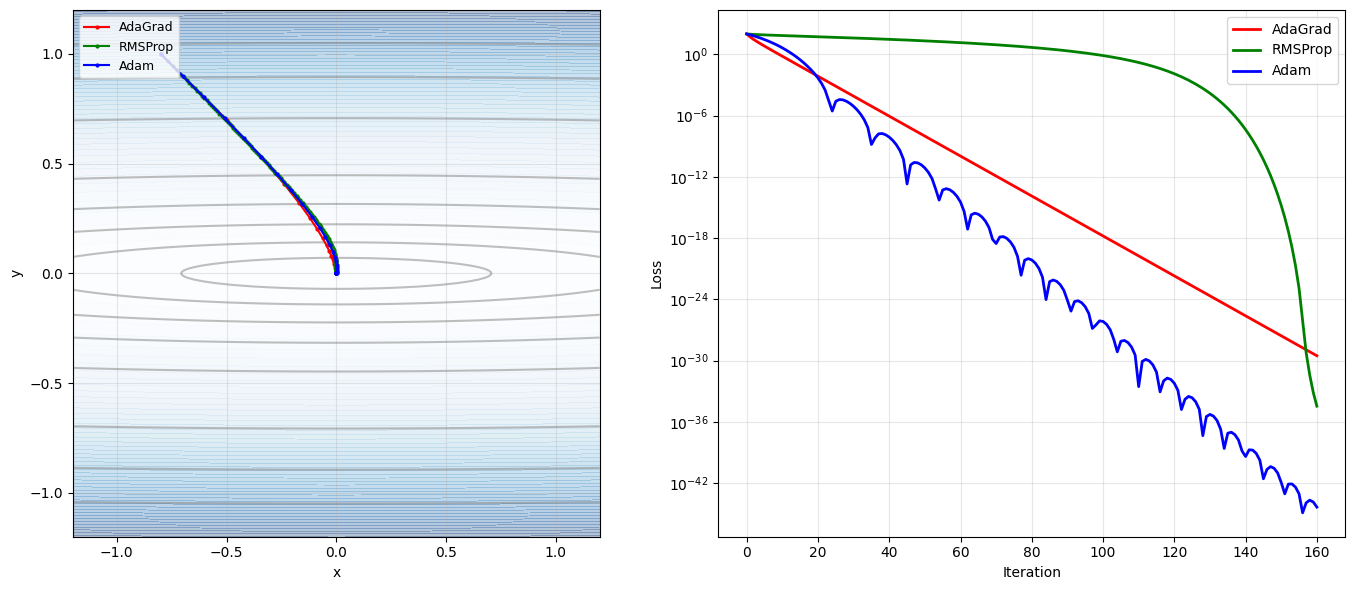

In [78]:
plot_data = [
    {'path': path_ada, 'label': 'AdaGrad', 'color': 'r', 'fmt': '.-', 'loss': losses_ada},
    {'path': path_rms, 'label': 'RMSProp', 'color': 'g', 'fmt': '.-', 'loss': losses_rms},
    {'path': path_adam, 'label': 'Adam', 'color': 'b', 'fmt': '.-', 'loss': losses_adam},
]

quick_plot(fn, w0, plot_data)


---
## Câu 1:

1. Cài đặt **hai phiên bản** Adam:
   - `adam_with_bc`: Adam **có** bias correction (chuẩn).
   - `adam_no_bc`: Adam **không có** bias correction (dùng trực tiếp $\mathbf{m}_t, \mathbf{v}_t$).

2. Chạy cả hai trên $f(x,y) = x^2 + 100y^2$, $\mathbf{w}_0 = (1,1)^T$, $\eta = 0.1$, `steps = 200`.

3. Vẽ figure gồm **2 subplot**:
   - **Subplot 1**: Loss Curve thang log, **zoom vào 30 bước đầu** để thấy rõ sự khác biệt.
   - **Subplot 2**: Bước nhảy $|\Delta \mathbf{w}_t| = \|\mathbf{w}_t - \mathbf{w}_{t-1}\|$ theo thời gian cho cả hai phiên bản.

4. Nhận xét (comment): Khi không có bias correction, điều gì xảy ra với bước nhảy ở iteration đầu tiên?


In [79]:
def adam_with_bc(grad_fn, w0, steps, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    w = w0.copy().astype(float)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = [w.copy()]

    for step in range(1, steps + 1):
        g = grad_fn(w)

        # Momentum
        m = beta1 * m + (1 - beta1) * g
        # RMSProp
        v = beta2 * v + (1 - beta2) * g**2

        # Bias correction
        m_hat = m / (1 - beta1**step)
        v_hat = v / (1 - beta2**step)

        w -= lr / (np.sqrt(v_hat) + eps) * m_hat
        path.append(w.copy())
    return np.array(path)

def adam_no_bc(grad_fn, w0, steps, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    w = w0.copy().astype(float)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = [w.copy()]

    for step in range(1, steps + 1):
        g = grad_fn(w)

        # Momentum
        m = beta1 * m + (1 - beta1) * g
        # RMSProp
        v = beta2 * v + (1 - beta2) * g**2

        w -= lr / (np.sqrt(v) + eps) * m
        path.append(w.copy())
    return np.array(path)

In [80]:
path_adam_with_bc = adam_with_bc(grad_fn, w0, lr=0.1, steps=200)
losses_adam_with_bc = [fn(p[0], p[1]) for p in path_adam_with_bc]

path_adam_no_bc = adam_no_bc(grad_fn, w0, lr=0.1, steps=200)
losses_adam_no_bc = [fn(p[0], p[1]) for p in path_adam_no_bc]

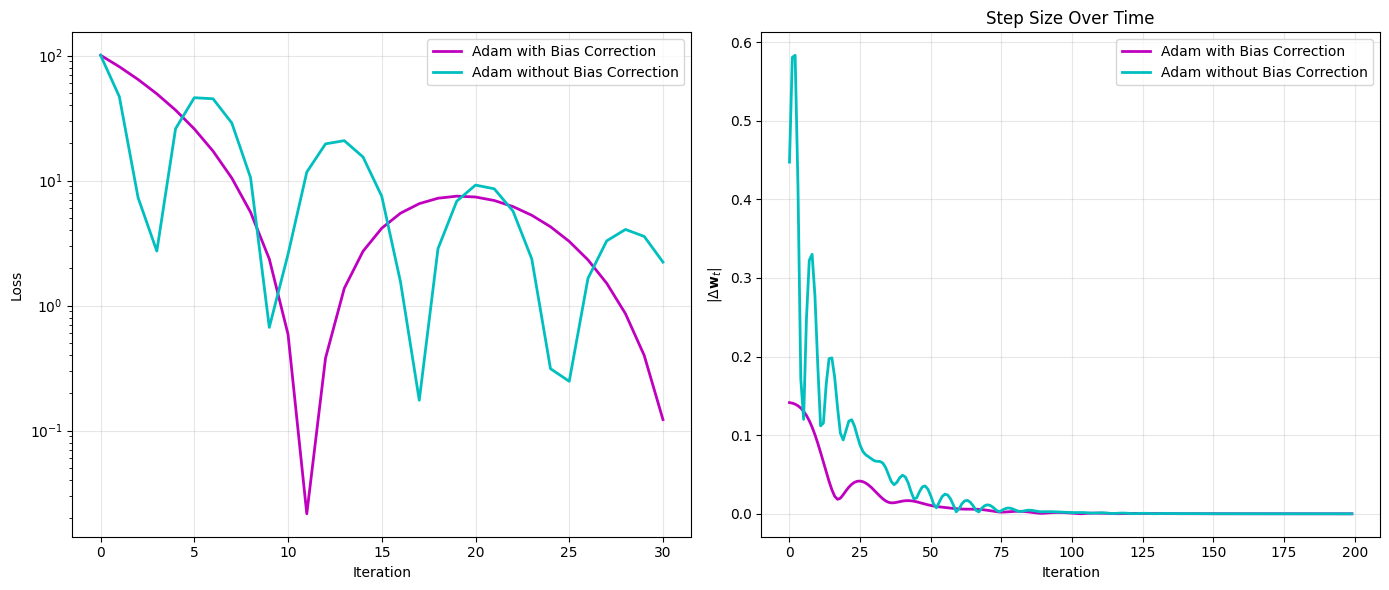

In [81]:
# Compute step sizes
step_sizes_with_bc = [np.linalg.norm(path_adam_with_bc[i] - path_adam_with_bc[i-1]) for i in range(1, len(path_adam_with_bc))]
step_sizes_no_bc = [np.linalg.norm(path_adam_no_bc[i] - path_adam_no_bc[i-1]) for i in range(1, len(path_adam_no_bc))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1:
ax1 = axes[0]
ax1.semilogy(losses_adam_with_bc[:31], color='m', linewidth=2, label='Adam with Bias Correction')
ax1.semilogy(losses_adam_no_bc[:31], color='c', linewidth=2, label='Adam without Bias Correction')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot 2:
ax2 = axes[1]
ax2.plot(step_sizes_with_bc, label='Adam with Bias Correction', color='m', linewidth=2)
ax2.plot(step_sizes_no_bc, label='Adam without Bias Correction', color='c', linewidth=2)

ax2.set_xlabel('Iteration')
ax2.set_ylabel(r'$|\Delta \mathbf{w}_t|$')
ax2.legend()
ax2.set_title('Step Size Over Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét**: Khi không có bias correction, bước nhảy ở iteraction đầu tiên lớn hơn rất nhiều so với có bias correction. Vì momentum và phương sai ban đầu bị đánh giá thấp, dẫn đến learning rate ban đầu quá cao.

---
## Câu 2:

1. Dùng hàm $f(x,y) = x^2 + 100y^2$, $\mathbf{w}_0 = (1,1)^T$, $\eta = 0.01$, `steps = 150`.

2. Chạy **RMSProp** với 4 giá trị $\beta \in \{0.5,\ 0.9,\ 0.99,\ 0.999\}$. Vẽ figure **2 subplot**:
   - Loss Curve (thang log) — label ghi kèm *effective window* $\approx \frac{1}{1-\beta}$.
   - Quỹ đạo trên contour của cả 4 cấu hình.

3. Chạy **Adam** với 4 giá trị $\beta_2 \in \{0.5,\ 0.9,\ 0.99,\ 0.999\}$ (giữ $\beta_1 = 0.9$). Vẽ tương tự.

4. Các bạn có nhận xét gì về các đường Curve ở từng trừng hợp



In [82]:
w0 = np.array([1, 1])
steps = 150

path_rms_1 = simple_rmsp(grad_fn, w0, lr=0.01, steps=steps, beta=0.5)
losses_rms_1 = [fn(p[0], p[1]) for p in path_rms_1]

path_rms_2 = simple_rmsp(grad_fn, w0, lr=0.01, steps=steps, beta=0.9)
losses_rms_2 = [fn(p[0], p[1]) for p in path_rms_2]

path_rms_3 = simple_rmsp(grad_fn, w0, lr=0.01, steps=steps, beta=0.99)
losses_rms_3 = [fn(p[0], p[1]) for p in path_rms_3]

path_rms_4 = simple_rmsp(grad_fn, w0, lr=0.01, steps=steps, beta=0.999)
losses_rms_4 = [fn(p[0], p[1]) for p in path_rms_4]

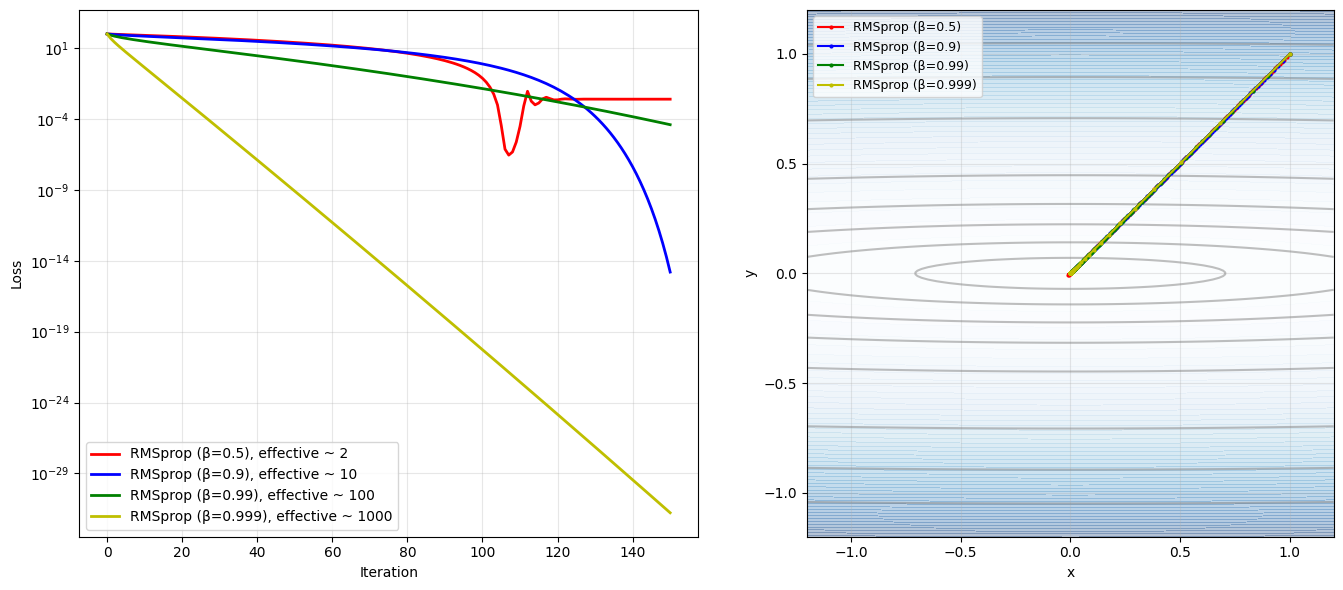

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1:
ax1 = axes[0]
ax1.semilogy(losses_rms_1, color='r', linewidth=2, label='RMSprop (β=0.5), effective ~ 2')
ax1.semilogy(losses_rms_2, color='b', linewidth=2, label='RMSprop (β=0.9), effective ~ 10')
ax1.semilogy(losses_rms_3, color='g', linewidth=2, label='RMSprop (β=0.99), effective ~ 100')
ax1.semilogy(losses_rms_4, color='y', linewidth=2, label='RMSprop (β=0.999), effective ~ 1000')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot 2:
ax2 = axes[1]
xr = np.linspace(-1.2, 1.2, 300)
yr = np.linspace(-1.2, 1.2, 300)
X_grid, Y_grid = np.meshgrid(xr, yr)
Z_grid = fn(X_grid, Y_grid)
levels = [0.5, 2, 5, 10, 20, 50, 80, 110]

ax2.contour(X_grid, Y_grid, Z_grid, levels=levels, colors='gray', alpha=0.5)
ax2.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap='Blues', alpha=0.3)

ax2.plot(path_rms_1[:,0], path_rms_1[:,1], '.-', color='r', markersize=4, linewidth=1.5, label='RMSprop (β=0.5)')
ax2.plot(path_rms_2[:,0], path_rms_2[:,1], '.-', color='b', markersize=4, linewidth=1.5, label='RMSprop (β=0.9)')
ax2.plot(path_rms_3[:,0], path_rms_3[:,1], '.-', color='g', markersize=4, linewidth=1.5, label='RMSprop (β=0.99)')
ax2.plot(path_rms_4[:,0], path_rms_4[:,1], '.-', color='y', markersize=4, linewidth=1.5, label='RMSprop (β=0.999)')

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:
w0 = np.array([1, 1])
steps = 150

path_adam_1 = simple_adam(grad_fn, w0, lr=0.01, steps=steps, beta2=0.5)
losses_adam_1 = [fn(p[0], p[1]) for p in path_adam_1]

path_adam_2 = simple_adam(grad_fn, w0, lr=0.01, steps=steps, beta2=0.9)
losses_adam_2 = [fn(p[0], p[1]) for p in path_adam_2]

path_adam_3 = simple_adam(grad_fn, w0, lr=0.01, steps=steps, beta2=0.99)
losses_adam_3 = [fn(p[0], p[1]) for p in path_adam_3]

path_adam_4 = simple_adam(grad_fn, w0, lr=0.01, steps=steps, beta2=0.999)
losses_adam_4 = [fn(p[0], p[1]) for p in path_adam_4]

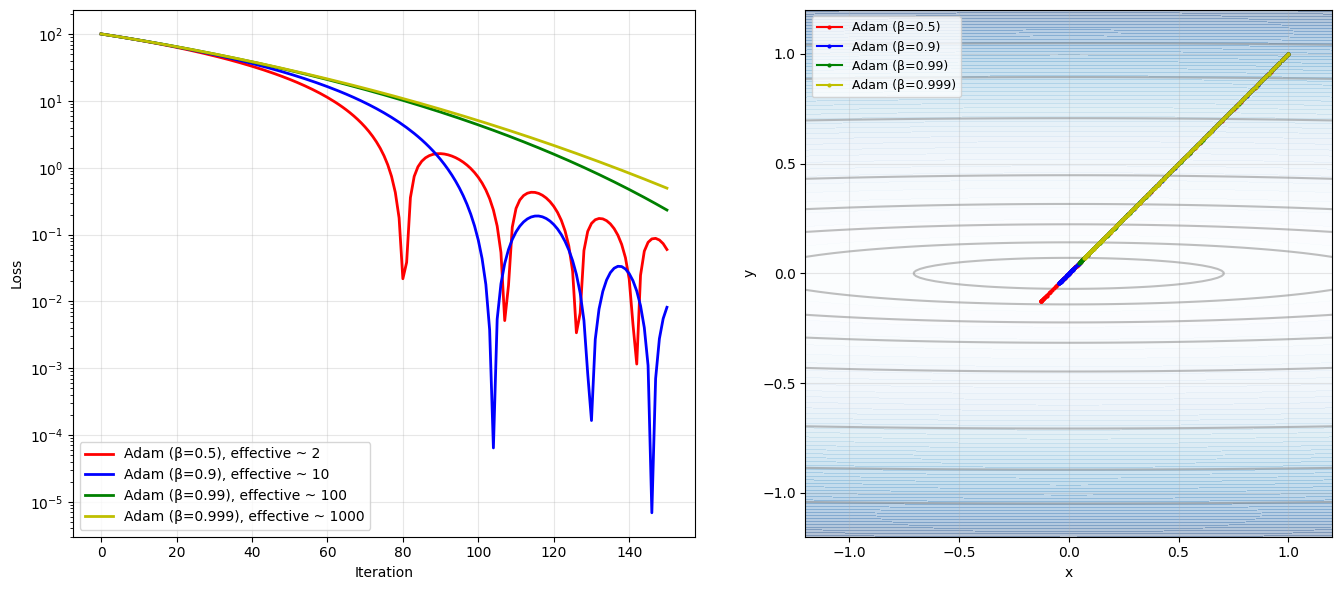

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1:
ax1 = axes[0]
ax1.semilogy(losses_adam_1, color='r', linewidth=2, label='Adam (β=0.5), effective ~ 2')
ax1.semilogy(losses_adam_2, color='b', linewidth=2, label='Adam (β=0.9), effective ~ 10')
ax1.semilogy(losses_adam_3, color='g', linewidth=2, label='Adam (β=0.99), effective ~ 100')
ax1.semilogy(losses_adam_4, color='y', linewidth=2, label='Adam (β=0.999), effective ~ 1000')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot 2:
ax2 = axes[1]
xr = np.linspace(-1.2, 1.2, 300)
yr = np.linspace(-1.2, 1.2, 300)
X_grid, Y_grid = np.meshgrid(xr, yr)
Z_grid = fn(X_grid, Y_grid)
levels = [0.5, 2, 5, 10, 20, 50, 80, 110]

ax2.contour(X_grid, Y_grid, Z_grid, levels=levels, colors='gray', alpha=0.5)
ax2.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap='Blues', alpha=0.3)

ax2.plot(path_adam_1[:,0], path_adam_1[:,1], '.-', color='r', markersize=4, linewidth=1.5, label='Adam (β=0.5)')
ax2.plot(path_adam_2[:,0], path_adam_2[:,1], '.-', color='b', markersize=4, linewidth=1.5, label='Adam (β=0.9)')
ax2.plot(path_adam_3[:,0], path_adam_3[:,1], '.-', color='g', markersize=4, linewidth=1.5, label='Adam (β=0.99)')
ax2.plot(path_adam_4[:,0], path_adam_4[:,1], '.-', color='y', markersize=4, linewidth=1.5, label='Adam (β=0.999)')

ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend(fontsize=9, loc='upper left')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Với RMSProp:
    - β=0.5: effective window ~2 nên cập nhật rất nhạy, bước đầu khá nhanh nhưng đường mất mát có thể hơi ít mượt. Do hàm này đối xứng, quỹ đạo vẫn thẳng theo đường chéo.
    - β=0.9: effective window ~10, là cân bằng tốt giữa tốc độ và ổn định. Curve giảm đều, không quá lớn, quỹ đạo vẫn đi thẳng đều về cực tiểu.
    - β=0.99: window ~100, bộ nhớ dài hơn, nên cập nhật chậm hơn và mượt hơn. Curve giảm chậm hơn so với β=0.9 nhưng ổn định hơn.
    - β=0.999: window ~1000, ban đầu v còn rất nhỏ nên bước cập nhật lớn, khiến giảm loss rất nhanh trong vài bước đầu; sau đó v tích lũy và bước nhảy trở nên rất nhỏ, do đó curve cuối cùng rất phẳng.

- Với Adam:
    - β2=0.5: moment bậc 2 rất ngắn hạn, v thay đổi nhanh, nên Adam nhạy và có thể giảm nhanh đầu tiên. Đường mất mát vẫn tương đối ổn.
    - β2=0.9: là cấu hình cân bằng, Adam hoạt động nhanh và mượt hơn so với β2 nhỏ.
    - β2=0.99: v mượt hơn, adaptation chậm hơn, curve giảm đều nhưng ít dốc hơn ban đầu.
    - β2=0.999: v rất trễ, bước đầu bị khống chế mạnh hơn, nên curve giảm chậm hơn trong giai đoạn đầu và ổn định về sau.

- So sánh chung:
    - Khi β tăng, đường mất mát thường càng mượt, nhưng tốc độ giảm ban đầu có thể chậm hơn (trừ trường hợp RMSProp β=0.999 do v nhỏ ban đầu tạo bước lớn).
    - Adam thường cho đường giảm tốt hơn so với RMSProp ở cùng β2 vì có thêm moment bậc 1 và bias correction.
    - Trên hàm này, các quỹ đạo đều đi gần đường chéo x=y, nên sự khác biệt chủ yếu là tốc độ giảm loss, không phải hướng đi.

---
## Câu 3:

Cho hàm số sau:

$$f(x, y) = (1-x)^2 + 100(y-x^2)^2$$

1. Hàm trên còn được gọi là `rosenbrock`. Hãy cài đặt `rosenbrock(x, y)` và `rosenbrock_grad(w)`.

2. Cài đặt `gd(grad_fn, w0, lr, steps)` — Gradient Descent cơ bản. Khởi tạo $\mathbf{w}_0 = (-1, 1)^T$, chạy **4 thuật toán** với `steps = 5000`:
   - GD: $\eta = 0.001$
   - AdaGrad: $\eta = 0.5$
   - RMSProp: $\eta = 0.01$, $\beta = 0.9$
   - Adam: $\eta = 0.01$

3. Vẽ figure **2 subplot**:
   - **Subplot 1**: Contour plot (dùng `np.log1p(Z)` để thấy rõ) + quỹ đạo 4 thuật toán.
   - **Subplot 2**: Loss Curve thang log.

4. Vẽ thêm subplot thứ 3: **khoảng cách đến cực tiểu** $d_t = \|\mathbf{w}_t - (1,1)^T\|$ theo bước lặp.

5. In ra: thuật toán nào đạt $d_t < 0.01$ nhanh nhất (số bước ít nhất)?


In [86]:
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(w):
    return np.array([-2 * (1 - w[0]) - 400 * w[0] * (w[1] - w[0]**2), 200 * (w[1] - w[0]**2)])

In [87]:
def gd(grad_fn, w0, lr, steps):
    w = w0.copy().astype(float)
    path = [w.copy()]
    for _ in range(steps):
        g = grad_fn(w)
        w -= lr * g
        path.append(w.copy())
    return np.array(path)

In [88]:
w0 = np.array([-1.0, 1.0])
steps = 5000

path_gd = gd(rosenbrock_grad, w0, lr=0.001, steps=steps)
losses_gd = [rosenbrock(p[0], p[1]) for p in path_gd]

path_ada = simple_adagrad(rosenbrock_grad, w0, lr=0.5, steps=steps)
losses_ada = [rosenbrock(p[0], p[1]) for p in path_ada]

path_rms = simple_rmsp(rosenbrock_grad, w0, lr=0.01, steps=steps, beta=0.9)
losses_rms = [rosenbrock(p[0], p[1]) for p in path_rms]

path_adam = simple_adam(rosenbrock_grad, w0, lr=0.01, steps=steps)
losses_adam = [rosenbrock(p[0], p[1]) for p in path_adam]

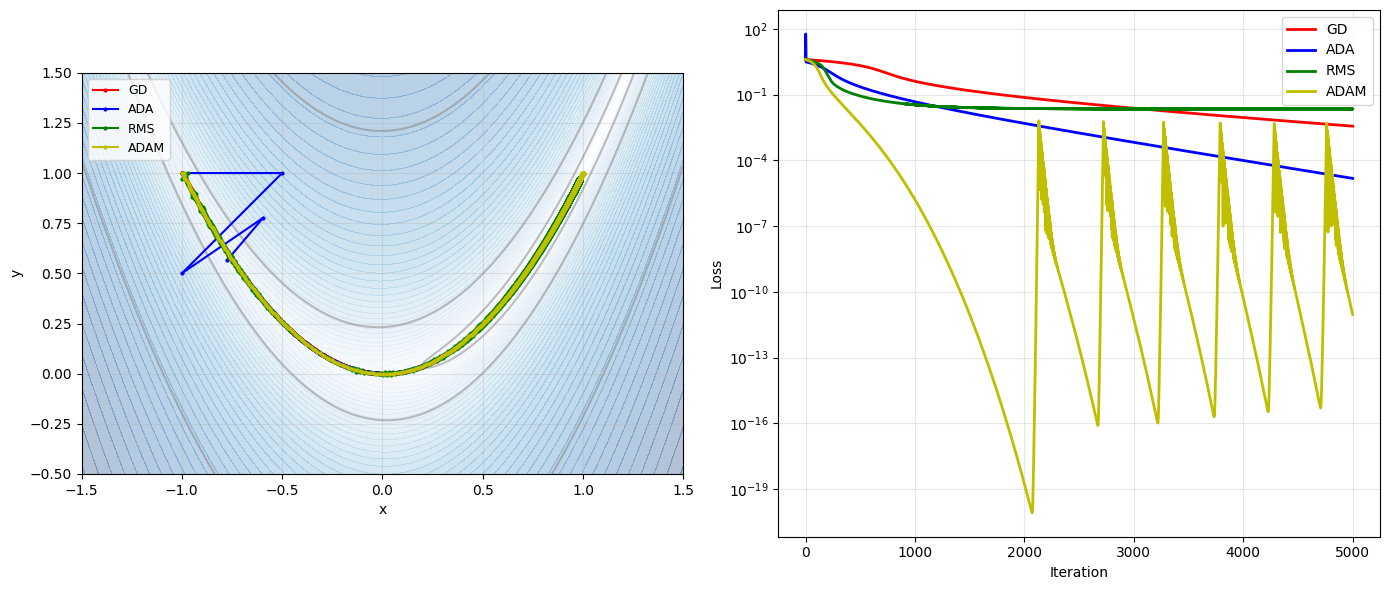

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: 
ax1 = axes[0]
xr = np.linspace(-1.5, 1.5, 300)
yr = np.linspace(-0.5, 1.5, 300)
X_grid, Y_grid = np.meshgrid(xr, yr)
Z_grid = np.log1p(rosenbrock(X_grid, Y_grid))
levels = [0.5, 2, 5, 10, 20, 50, 80, 110]

ax1.contour(X_grid, Y_grid, Z_grid, levels=levels, colors='gray', alpha=0.5)
ax1.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap='Blues', alpha=0.3)

ax1.plot(path_gd[:,0], path_gd[:,1], '.-', color='r', markersize=4, linewidth=1.5, label='GD')
ax1.plot(path_ada[:,0], path_ada[:,1], '.-', color='b', markersize=4, linewidth=1.5, label='ADA')
ax1.plot(path_rms[:,0], path_rms[:,1], '.-', color='g', markersize=4, linewidth=1.5, label='RMS')
ax1.plot(path_adam[:,0], path_adam[:,1], '.-', color='y', markersize=4, linewidth=1.5, label='ADAM')

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend(fontsize=9, loc='upper left')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Subplot 2:
ax2 = axes[1]
ax2.semilogy(losses_gd, color='r', linewidth=2, label='GD')
ax2.semilogy(losses_ada, color='b', linewidth=2, label='ADA')
ax2.semilogy(losses_rms, color='g', linewidth=2, label='RMS')
ax2.semilogy(losses_adam, color='y', linewidth=2, label='ADAM')

ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

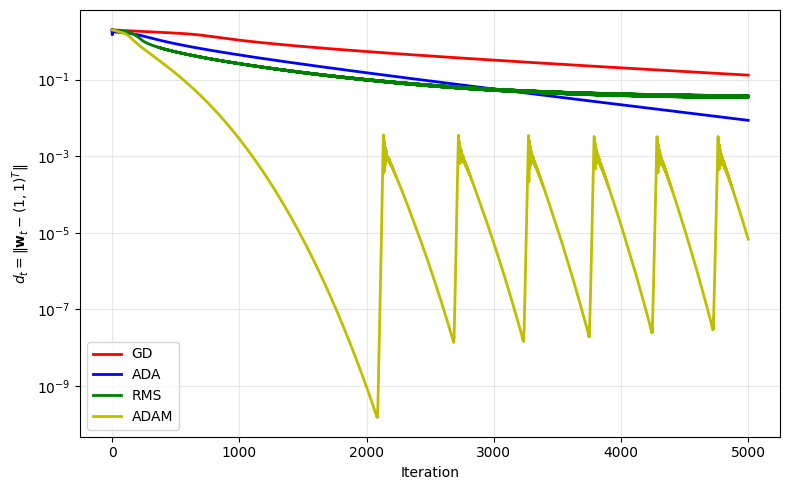

In [90]:
dist_gd = [np.linalg.norm(p - np.array([1, 1])) for p in path_gd]
dist_ada = [np.linalg.norm(p - np.array([1, 1])) for p in path_ada]
dist_rms = [np.linalg.norm(p - np.array([1, 1])) for p in path_rms]
dist_adam = [np.linalg.norm(p - np.array([1, 1])) for p in path_adam]

plt.figure(figsize=(8, 5))
plt.semilogy(dist_gd, color='r', linewidth=2, label='GD')
plt.semilogy(dist_ada, color='b', linewidth=2, label='ADA')
plt.semilogy(dist_rms, color='g', linewidth=2, label='RMS')
plt.semilogy(dist_adam, color='y', linewidth=2, label='ADAM')

plt.xlabel('Iteration')
plt.ylabel(r'$d_t = \|\mathbf{w}_t - (1,1)^T\|$')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
algorithms = ['GD', 'ADA', 'RMS', 'ADAM']  
distances = [dist_gd, dist_ada, dist_rms, dist_adam]

for alg, dist in zip(algorithms, distances):
    dist_arr = np.array(dist)
    # np.where trả về tuple các index thỏa mãn điều kiện
    valid_indices = np.where(dist_arr < 0.01)[0] 
    
    if len(valid_indices) > 0:
        print(f"{alg} đạt d_t < 0.01 tại bước {valid_indices[0]}")
    else:
        print(f"{alg} không đạt được d_t < 0.01")

GD không đạt được d_t < 0.01
ADA đạt d_t < 0.01 tại bước 4847
RMS không đạt được d_t < 0.01
ADAM đạt d_t < 0.01 tại bước 864


---
## Câu 4:
Cho điểm dữ liệu thứ $i$ có vector đặc trưng $\mathbf{x}^{(i)}$ và nhãn $y^{(i)} \in \{0, 1\}$. Ma trận trọng số là $\mathbf{w}$. Hãy giải quyết các vấn đề sau:


1. Tạo tập dữ liệu bằng `sklearn.datasets.make_classification ($N=5000$, n_features=20, n_informative=10, n_redundant=5, random_state=42)`. Sử dụng hàm `train_test_split` từ `sklearn`.model_selection để chia $X$ và $y$ thành các tập `X_train, X_test, y_train, y_test` với tỉ lệ 80% dùng để huấn luyện `(test_size=0.2)`. Thực hiện nối cột bias 1 vào ma trận đặc trưng bằng `np.hstack`.

2. Cài đặt hàm tính Binary Cross-Entropy Loss $J(\mathbf{w})$ và vector gradient $\nabla_{\mathbf{w}} J(\mathbf{w})$ trung bình trên một mini-batch có kích thước $m$ `compute_grads(X_b, y_b, w)`, biết rằng ta có các công thức dạng vector hóa như sau:

$$
J(\mathbf{w}) = -\frac{1}{m} \left[ (Y^{(i)})^T \log(\mathbf{\hat{Y}}^{(i)}) + (1 - Y^{(i)})^T \log(1 - \mathbf{\hat{Y}}^{(i)}) \right]
$$

$$
\nabla_{\mathbf{w}} J(\mathbf{w}) = \frac{1}{m} (\mathbf{X}^{(i)})^T (\mathbf{\hat{Y}}^{(i)} - Y^{(i)})
$$

   Biết rằng:

$$\hat{Y}^{(i)} = \frac{1}{1 + e^{-\mathbf{X}^{(i)}\mathbf{W}}}$$

Với $i$ là batch thứ $i$-th, $m$ là kích thước của `batch_size` ở batch thứ $i$

3. Cài đặt `create_mini_batches(X, y, batch_size)` xáo trộn và cắt batch.

4. Giải quyết bài toán trên sử dụng **4 thuật toán** tối ưu và các siêu tham số `epochs=100`, `lr=0.001`, `batch_size=64`:
   - **SGD**
   - **AdaGrad**
   - **RMSProp** ($\beta=0.9$)
   - **Adam** ($\beta_1=0.9$, $\beta_2=0.999$)

5. Vẽ figure **2 subplot**: Train Loss Curve và Test Accuracy Curve theo epoch.

6. In bảng tóm tắt dạng:
```
Thuật toán  | Train Loss | Test Acc
------------|------------|----------
SGD         |  ...       |  ...
AdaGrad     |  ...       |  ...
RMSProp     |  ...       |  ...
Adam        |  ...       |  ...
```


In [92]:
import sklearn.datasets

X, y = sklearn.datasets.make_classification(n_samples=5000, n_features=20, n_informative=10, n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

In [93]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_grads(X_b, y_b, w):
    m = X_b.shape[0]
    
    y_hat = sigmoid(np.dot(X_b, w))
    
    epsilon = 1e-15
    y_hat_clip = np.clip(y_hat, epsilon, 1 - epsilon)
    
    loss = - (1/m) * (np.dot(y_b.T, np.log(y_hat_clip)) + np.dot((1 - y_b).T, np.log(1 - y_hat_clip)))
    loss = np.squeeze(loss) 
    
    grad = (1/m) * np.dot(X_b.T, (y_hat - y_b))
    
    return loss, grad

In [94]:
def create_mini_batches(X, y, batch_size):
    n = len(X)
    indices = np.random.permutation(n)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    mini_batches = []
    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]
        mini_batches.append((X_batch, y_batch))
        
    return mini_batches

In [95]:
np.random.seed(1)
lr = 0.001
epochs = 100
batch_size = 64

In [96]:
def calculate_accuracy(X, y, w):
    preds = sigmoid(np.dot(X, w)) >= 0.5
    return np.mean(preds == y)

In [97]:
def train(algorithm):
    w = np.zeros(X_train.shape[1])
    v = np.zeros_like(w)
    m_t = np.zeros_like(w)
    beta1, beta2 = 0.9, 0.999
    beta_rms = 0.9
    epsilon = 1e-8
    t = 0
    
    train_loss = []
    test_acc = []

    for i in range(epochs):
        mini_batches = create_mini_batches(X_train, y_train, batch_size)
        epoch_loss = 0

        for X_batch, y_batch in mini_batches:
            loss, grad = compute_grads(X_batch, y_batch, w)

            epoch_loss += loss * X_batch.shape[0]
            
            if algorithm == 'SGD':
                w -= lr * grad
            elif algorithm == 'AdaGrad':
                v = v + grad**2
                w = w - (lr / (np.sqrt(v) + epsilon)) * grad
            elif algorithm == 'RMSProp':
                v = beta_rms * v + (1 - beta_rms) * grad**2
                w = w - (lr / (np.sqrt(v) + epsilon)) * grad
            else:
                t += 1
                m_t = beta1 * m_t + (1 - beta1) * grad
                v = beta2 * v + (1 - beta2) * grad**2
                # Hiệu chỉnh bias (bias correction)
                m_hat = m_t / (1 - beta1**t)
                v_hat = v / (1 - beta2**t)
                w = w - (lr / (np.sqrt(v_hat) + epsilon)) * m_hat

        train_loss.append(epoch_loss / X_train.shape[0])
        
        test_acc.append(calculate_accuracy(X_test, y_test, w))
    
    return train_loss, test_acc

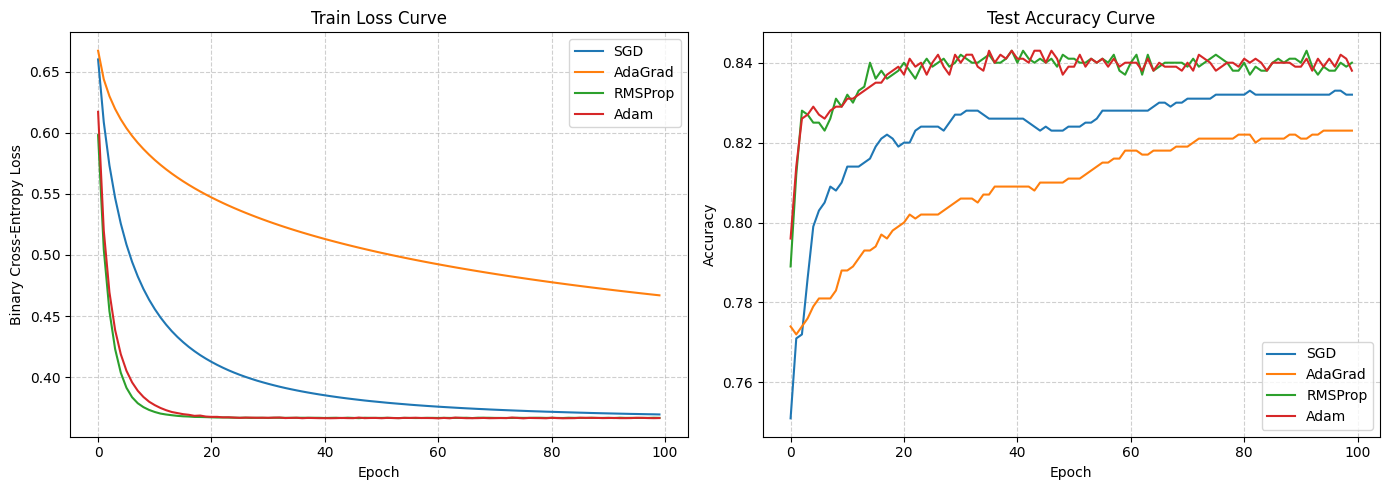

In [98]:
algorithm = ['SGD', 'AdaGrad', 'RMSProp', 'Adam']
results = {}
for opt in algorithm:
    results[opt] = train(opt)

plt.figure(figsize=(14, 5))

# Subplot 1:
plt.subplot(1, 2, 1)
for opt in algorithm:
    plt.plot(results[opt][0], label=opt)
plt.title('Train Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2:
plt.subplot(1, 2, 2)
for opt in algorithm:
    plt.plot(results[opt][1], label=opt)
plt.title('Test Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [99]:
print(f"Thuật toán  | Train Loss | Test Acc")
print("------------|------------|----------")
for opt in algorithm:
    final_loss = results[opt][0][-1]
    final_acc = results[opt][1][-1]
    print(f"{opt:<11} | {final_loss:<11.4f}| {final_acc:<10.4f}")

Thuật toán  | Train Loss | Test Acc
------------|------------|----------
SGD         | 0.3695     | 0.8320    
AdaGrad     | 0.4670     | 0.8230    
RMSProp     | 0.3667     | 0.8400    
Adam        | 0.3665     | 0.8380    
